In [9]:
import collections
from IPython import display
import matplotlib.pyplot as plt

import numpy as np
import torch
import itertools as itr
from scipy.special import softmax
from torch import nn
from common.ffn.ffn_relu import ParametricReLUNet
from common.coeff_calc.coeff_calc_ntk import NTKSimulator
from sklearn.metrics import mean_squared_error

from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from util import *
import logging

In [10]:
logging.basicConfig(filename="Log_Test_File.txt",
                level=logging.DEBUG,
                format='%(levelname)s: %(asctime)s %(message)s',
                datefmt='%m/%d/%Y %I:%M:%S')

In [11]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = MNIST(root='./', train=True, download=True, transform=image_transform)
test_dataset = MNIST(root='./', train=False, download=True, transform=image_transform)

In [12]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

In [13]:
class MNISTReLU(ParametricReLUNet):
    def __init__(self, input_dim, output_dim):
        super().__init__(n0=input_dim,nk=0,nl=output_dim,l=0, bias_on=True)

        self.input_fc = nn.Linear(input_dim, 250)
        self.hidden_fc = nn.Linear(250, 100)
        self.output_fc = nn.Linear(100, output_dim)

    def forward_(self, x):
        return self.forward(x)

    def forward(self, x):
        #x = [batch size, height, width]
        #x = [batch size, height * width]
        h_1 = self.PReLU(self.input_fc(x))
        #h_1 = [batch size, 250]
        h_2 = self.PReLU(self.hidden_fc(h_1))
        #h_2 = [batch size, 100]
        y_pred = self.output_fc(h_2)
        #y_pred = [batch size, output dim]
        return y_pred
    
    def init_weights(self, cb=0.0, cw=1.0):
        if self.get_log_level() == "debug":
            print("FeedForwardNet weights initialisation with cb={}, cw={}".format(cb, cw))

        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        self.init_linear_weights(self.input_fc, self.bias_on, cb, cw/self.input_fc.in_features)
        self.init_linear_weights(self.hidden_fc, self.bias_on, cb, cw/self.hidden_fc.in_features)
        self.init_linear_weights(self.output_fc, self.bias_on, cb, cw/self.output_fc.in_features)


In [14]:
INPUT_DIM = 28 * 28
OUTPUT_DIM = 10  # num classes

ln=3
lb, lw, eta = 1e-2, 1e-1, 1 #1e-2,1,1 #1e-2, 1e-2, 1
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

testNet = MNISTReLU(INPUT_DIM, OUTPUT_DIM)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)

FeedForwardNet created with n0=784, nk=0, nl=10, l=0, bias_on=True


In [15]:
def PReLUz(input: float) -> float:
    return slope_plus * input if input >= 0 else slope_minus * input

def PReLUdrv(input: float) -> float:
    return slope_plus if input >= 0 else slope_minus

act = np.vectorize(PReLUz)
drv = np.vectorize(PReLUdrv)

def adjust_and_forward_(delta_weight_0, delta_bias_0, delta_weight_1, delta_bias_1,\
                        delta_weight_2, delta_bias_2, coeff, xx):
    with torch.no_grad():
        testNet.input_fc.weight += torch.from_numpy(delta_weight_0) * coeff
        testNet.input_fc.bias += torch.from_numpy(delta_bias_0) * coeff
        testNet.hidden_fc.weight += torch.from_numpy(delta_weight_1) * coeff
        testNet.hidden_fc.bias += torch.from_numpy(delta_bias_1) * coeff
        testNet.output_fc.weight += torch.from_numpy(delta_weight_2) * coeff
        testNet.output_fc.bias += torch.from_numpy(delta_bias_2) * coeff
        logits = testNet.forward_(xx)
        prediction = logits.argmax(dim=-1)
    return logits, prediction

LOGIT_DELTA = 0.1
#[output dim, batch size]
def labels_to_logits(labels, zz, iteration_num):
    batch_size = labels.shape[0]
    yy = np.full((OUTPUT_DIM, batch_size), -3.0)
    for batch_num in range(batch_size):
        '''
        for output_num in range(OUTPUT_DIM):
            yy[output_num, batch_num] = \
                max(3, zz[output_num, batch_num])+LOGIT_DELTA \
                    if output_num == labels[batch_num] \
                    else min(-3, zz[output_num, batch_num])-LOGIT_DELTA #, -3*LOGIT_DELTA-0.01*iteration_num)
        '''
        yy[labels[batch_num], batch_num] = 3 #+0.01*iteration_num

    logging.debug("Logits for iteration {}: {}".format(iteration_num, np.transpose(yy)))
    return yy

'''
def loss_mse(output_tensor, true_labels):
    zz_numpy = np.transpose(output_tensor.detach().numpy())
    return mean_squared_error(true_labels, zz_numpy)
'''

def loss_crossentropy(output_tensor, pp_tensor):
    zz = np.transpose(output_tensor.detach().numpy())
    #print(zz)
    qq = softmax(zz, axis=(0))
    #print(qq)
    pp_raw = pp_tensor.detach().numpy()
    #print(pp_raw)
    pp = np.zeros_like(qq)
    for col in range(len(pp_raw)):
        pp[pp_raw[col],col]=1
    #print(pp)
    return -np.sum(pp * np.log(qq))
    #print(result)
    #raise ValueError
    #return result

def visualise():
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    axes[0].set_title('Loss (MSE)')
    axes[0].plot(HISTORY_PARAMS['train_loss'], label='Train Loss')
    axes[0].plot(HISTORY_PARAMS['test_loss'], label='Test Loss')
    axes[0].grid()
    axes[0].legend(fontsize=20)
    
    axes[1].set_title('Accuracy')
    axes[1].plot(HISTORY_PARAMS['train_accuracy'], label='Train Accuracy')
    axes[1].plot(HISTORY_PARAMS['test_accuracy'], label='Test Accuracy')
    axes[1].grid()
    axes[1].legend(fontsize=20)
    
    plt.show()

NUM_EPOCH = 500
HISTORY_PARAMS = collections.defaultdict(list)

#### LOOP STARTS HERE

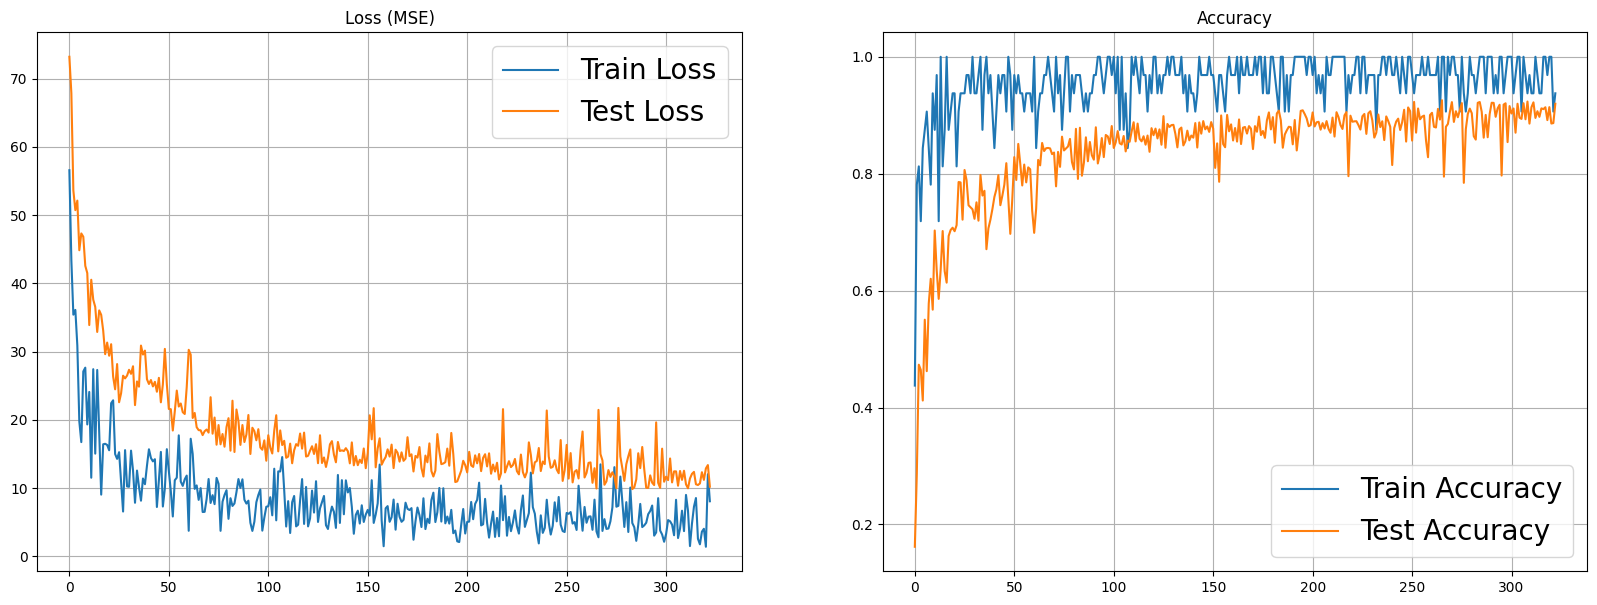

-

In [16]:
tol_mse_delta = 1e-8
iteration_num = 0
global_accur, global_loss = 0.0, 1000.0

#Nesterov params: https://pytorch.org/docs/stable/generated/torch.optim.SGD.html
momentum, lr, dampening, nesterov = 0.0, 0.5, 0.0, True#0.7, 0.5, 0.0, True #0.9, 0.5, 0.0, True
bb_weight_0 = np.zeros((250, 784))
bb_bias_0 = np.zeros((250))
bb_weight_1 = np.zeros((100, 250))
bb_bias_1 = np.zeros((100))
bb_weight_2 = np.zeros((10, 100))
bb_bias_2 = np.zeros((10))

while iteration_num < NUM_EPOCH: #and (old_global_mse - new_global_mse) > -0.5:
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter()
    # training part
    #old_global_mse = new_global_mse
    images, labels = next(iter(train_dataloader))
    #images = [batch_size, height, width]
    batch_size = images.shape[0]
    xx = images.view(batch_size, -1)
    #xx = [batch_size, height * width]
    #NTK calculation
    KK = np.zeros((ln, BATCH_SIZE, BATCH_SIZE))
    Theta = np.zeros_like(KK)
    sim = NTKSimulator(cb=cb, cw=cw, lb=lb, lw=lw, act=act, drv=drv, n_samples=1000000)
    sim.calculate_layer0(KK, Theta, np.transpose(xx.detach().numpy()))
    for idx in range(1, ln):
        sim.calculate_layer(KK, Theta, idx)
        print('-', end='')

    #Forward step and derivatives
    logits = testNet.forward_(xx)

    #dz^(L)_(k;α2)/dθμ
    #print("Calculating derivatives")
    input_fc_weight = np.zeros((OUTPUT_DIM, BATCH_SIZE, 250, 784))
    input_fc_bias = np.zeros((OUTPUT_DIM, BATCH_SIZE, 250))
    hidden_fc_weight = np.zeros((OUTPUT_DIM, BATCH_SIZE, 100, 250))
    hidden_fc_bias = np.zeros((OUTPUT_DIM, BATCH_SIZE, 100))
    output_fc_weight = np.zeros((OUTPUT_DIM, BATCH_SIZE, 10, 100))
    output_fc_bias = np.zeros((OUTPUT_DIM, BATCH_SIZE, 10))

    for kk, alpha in itr.product(range(OUTPUT_DIM), range(BATCH_SIZE)):
        df = torch.autograd.grad(logits[alpha,kk], (testNet.input_fc.weight, testNet.input_fc.bias\
                                        , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                        , testNet.output_fc.weight, testNet.output_fc.bias)\
            , retain_graph=True, create_graph=True, allow_unused=True)    
        input_fc_weight[kk, alpha] = df[0].detach().numpy()
        input_fc_bias[kk, alpha] = df[1].detach().numpy()
        hidden_fc_weight[kk, alpha] = df[2].detach().numpy()
        hidden_fc_bias[kk, alpha] = df[3].detach().numpy()
        output_fc_weight[kk, alpha] = df[4].detach().numpy()
        output_fc_bias[kk, alpha] = df[5].detach().numpy()
    #print("Derivatives calculated")

    #Parameters update and recalculation
    #κ^(α˜2;α˜3)
    thetal = Theta[-1]
    eta_ktop = np.linalg.inv(thetal) #(10.25)

    #[dLA/dz(k;α1)]*k^(α1;α2)
    zz = np.transpose(logits.detach().numpy())
    yy = labels_to_logits(labels, zz, iteration_num)

    #print("Calculating deltas")
    term = -1*np.matmul((zz - yy), eta_ktop)
    delta_weight_0 = np.tensordot(term, input_fc_weight, axes=([0,1],[0,1])) * (lw/input_fc_weight.shape[3])
    delta_bias_0 = np.tensordot(term, input_fc_bias, axes=([0,1],[0,1])) * lb
    delta_weight_1 = np.tensordot(term, hidden_fc_weight, axes=([0,1],[0,1])) * (lw/hidden_fc_weight.shape[3])
    delta_bias_1 = np.tensordot(term, hidden_fc_bias, axes=([0,1],[0,1])) * lb
    delta_weight_2 = np.tensordot(term, output_fc_weight, axes=([0,1],[0,1])) * (lw/output_fc_weight.shape[3])
    delta_bias_2 = np.tensordot(term, output_fc_bias, axes=([0,1],[0,1])) * lb

    if momentum > 0:
        '''
        if iteration_num % 3 == 0:
            bb_weight_0.fill(0.0)
            bb_bias_0.fill(0.0)
            bb_weight_1.fill(0.0)
            bb_bias_1.fill(0.0)
            bb_weight_2.fill(0.0)
            bb_bias_2.fill(0.0)
        '''
        if iteration_num > 0:
            bb_weight_0 = momentum*bb_weight_0 + (1-dampening)*delta_weight_0
            bb_bias_0 = momentum*bb_bias_0 + (1-dampening)*delta_bias_0
            bb_weight_1 = momentum*bb_weight_1 + (1-dampening)*delta_weight_1
            bb_bias_1 = momentum*bb_bias_1 + (1-dampening)*delta_bias_1
            bb_weight_2 = momentum*bb_weight_2 + (1-dampening)*delta_weight_2
            bb_bias_2 = momentum*bb_bias_2 + (1-dampening)*delta_bias_2
        else:
            bb_weight_0 = delta_weight_0
            bb_bias_0 = delta_bias_0
            bb_weight_1 = delta_weight_1
            bb_bias_1 = delta_bias_1
            bb_weight_2 = delta_weight_2
            bb_bias_2 = delta_bias_2
        if nesterov:
            delta_weight_0 = lr*(delta_weight_0 + momentum*bb_weight_0)
            delta_bias_0 = lr*(delta_bias_0 + momentum*bb_bias_0)
            delta_weight_1 = lr*(delta_weight_1 + momentum*bb_weight_1)
            delta_bias_1 = lr*(delta_bias_1 + momentum*bb_bias_1)
            delta_weight_2 = lr*(delta_weight_2 + momentum*bb_weight_2)
            delta_bias_2 = lr*(delta_bias_2 + momentum*bb_bias_2)
        else:
            delta_weight_0 = bb_weight_0
            delta_bias_0 = bb_bias_0
            delta_weight_1 = bb_weight_1
            delta_bias_1 = bb_bias_1
            delta_weight_2 = bb_weight_2
            delta_bias_2 = bb_bias_2
    #print("Deltas calculated")

    old_accur, old_loss = calculate_accuracy(logits.argmax(dim=-1), labels), loss_crossentropy(logits, labels) #mean_squared_error(yy, zz)
    logits_adjusted, prediction_adjusted = None, None
    log_message = "Initial params in iteration {} :accuracy={}, cross_enthropy={}"\
        .format(iteration_num, old_accur, old_loss)
    coeff = 0.1

    while coeff >= 0.001:
        logits_adjusted, prediction_adjusted = adjust_and_forward_(delta_weight_0, delta_bias_0,\
                        delta_weight_1, delta_bias_1, delta_weight_2, delta_bias_2, coeff, xx)
        new_accur, new_loss = calculate_accuracy(prediction_adjusted, labels), loss_crossentropy(logits_adjusted, labels)
        log_message += "Params after step={} :accuracy={}, cross_enthropy={}".format(coeff, new_accur, new_loss)
        if (new_accur - old_accur < 0) or (new_loss - old_loss) >= -tol_mse_delta:
            if (new_accur - old_accur < 0) or (new_loss - old_loss) > 0:
                logits_adjusted, prediction_adjusted = adjust_and_forward_(delta_weight_0, delta_bias_0,\
                        delta_weight_1, delta_bias_1, delta_weight_2, delta_bias_2, -1*coeff, xx)
                new_accur, new_loss = calculate_accuracy(prediction_adjusted, labels), loss_crossentropy(logits_adjusted, labels)
                log_message += "Params after step={} :accuracy={}, cross_enthropy={}".format(-1*coeff, new_accur, new_loss)
            
            coeff *= 0.1
        old_accur, old_loss = new_accur, new_loss

    global_accur, global_loss = old_accur, old_loss
    logging.debug(log_message)
    # save average train loss and accuracy
    HISTORY_PARAMS['train_loss'].append(global_loss)
    HISTORY_PARAMS['train_accuracy'].append(global_accur)

    # testing loop
    for test_images, test_labels in test_dataloader:
        test_batch_size = test_images.shape[0]
        test_xx = test_images.view(test_batch_size, -1)
        with torch.no_grad():
            test_logits = testNet.forward_(test_xx)
            test_prediction = test_logits.argmax(dim=-1)

        test_loss_meter.update(loss_crossentropy(test_logits, test_labels))
        test_accuracy_meter.update(calculate_accuracy(test_prediction, test_labels))            
    # save average test accuracy loss and accuracy
    HISTORY_PARAMS['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise()
    iteration_num += 1
